In [8]:
import sys

sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

#load the necessary odometry modules
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.test_benches.combined_pc_kalman_tb import combinedPointCloudKalmanTB
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.plotting.movies import MovieGenerator


In [9]:
#setup the datasets
#initial experiments: "/data/radnav/rad_nav_rotate_experiments/wilk_origin_forward/"

dataset = radnavDS(
    dataset_path="/home/undergrads/documents/WILK_Long_Movement",
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder="/data/radnav/maps",
    map_file="wilkinson.yaml"
)

found 2858 radar samples
found 2858 lidar samples
found 2858 camera samples
found 2858 imu (orientation only) samples
found 2858imu (full data) samples
found 2858 vehicle velocity samples
loaded map from /data/radnav/maps/wilkinson.yaml


In [10]:
#initialize the localizers
radar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.3,#originally 0.5
    icp_best_points_percentile=75,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=7, #originally 5
    icp_max_iterations=20,
    self_detection_radius_m=0.5 #originally 0.25
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.6, #originally 0.6
    icp_best_points_percentile=50,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=0.25
)

loaded map with 20750 points
loaded map with 20750 points
gt icp estimated heading:-4.109902858622215 deg, pose:[-0.0855056   0.19063337]
radar icp estimated heading:-4.848256269015724 deg, pose:[-0.02500162  0.17201425]


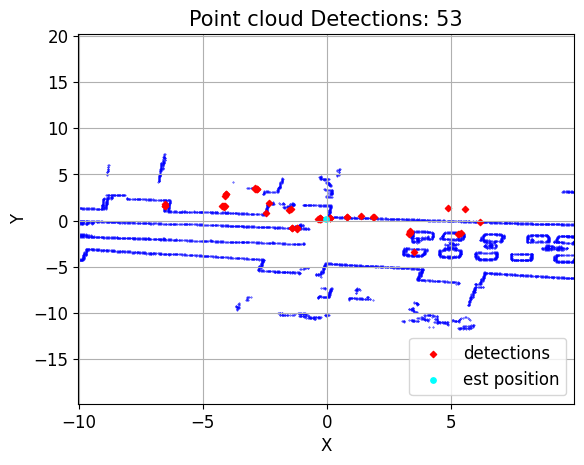

In [11]:
filter_threshold = 0.035

#initialize the test bench
test_bench = combinedPointCloudKalmanTB(
    localizer=radar_odometry,
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset,
    vel_filter_v_thresh = filter_threshold,
    vel_filter_enabled = True,
    min_static_rejection_radius = 1.5,
    dynamic_cluster_eps = 1.0,
    dynamic_cluster_min_samples = 7
)

start_heading = np.deg2rad(-6.1)
start_pose = np.array([0.03,0.11])

new_heading_rad,new_pose_m = test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    show=True
)

In [12]:
#initialize the kalman filter
start_time_s = test_bench.get_dataset_start_time(idx=0)
print("dataset start time: {}s".format(start_time_s))

test_bench.init_filter(
    est_start_heading_rad=start_heading,
    est_start_position_m=start_pose,
    start_time_s=start_time_s
)

dataset start time: 1719414552.7333257s


found temp dir: /home/undergrads/documents/Odometry
clearing temp directory /home/undergrads/documents/Odometry


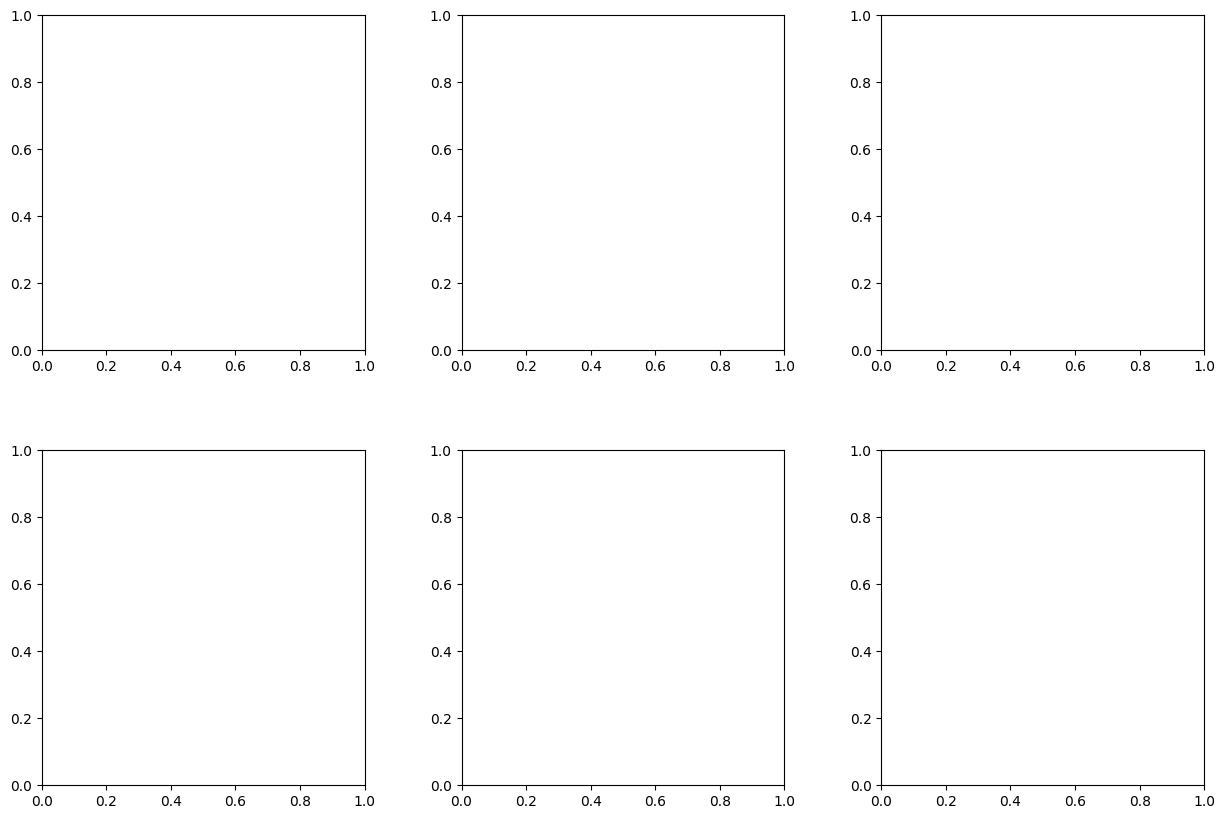

In [13]:
#initialize the movie maker
movie_generator = MovieGenerator(
    temp_dir_path="/home/undergrads/documents/Odometry"
)
movie_generator.initialize_figure(
    nrows=2,
    ncols=3,
    figsize=(15,10)
)

In [14]:
end_idx = dataset.num_frames
test_bench.run(
    max_frame=end_idx,
    gt_enabled=False,
    movie_generator=None) #=movie_generator)

100%|██████████| 2858/2858 [00:10<00:00, 262.38it/s]


In [15]:
movie_generator.save_movie(video_file_name="wilkmovement.mp4",fps=20)

0it [00:00, ?it/s]


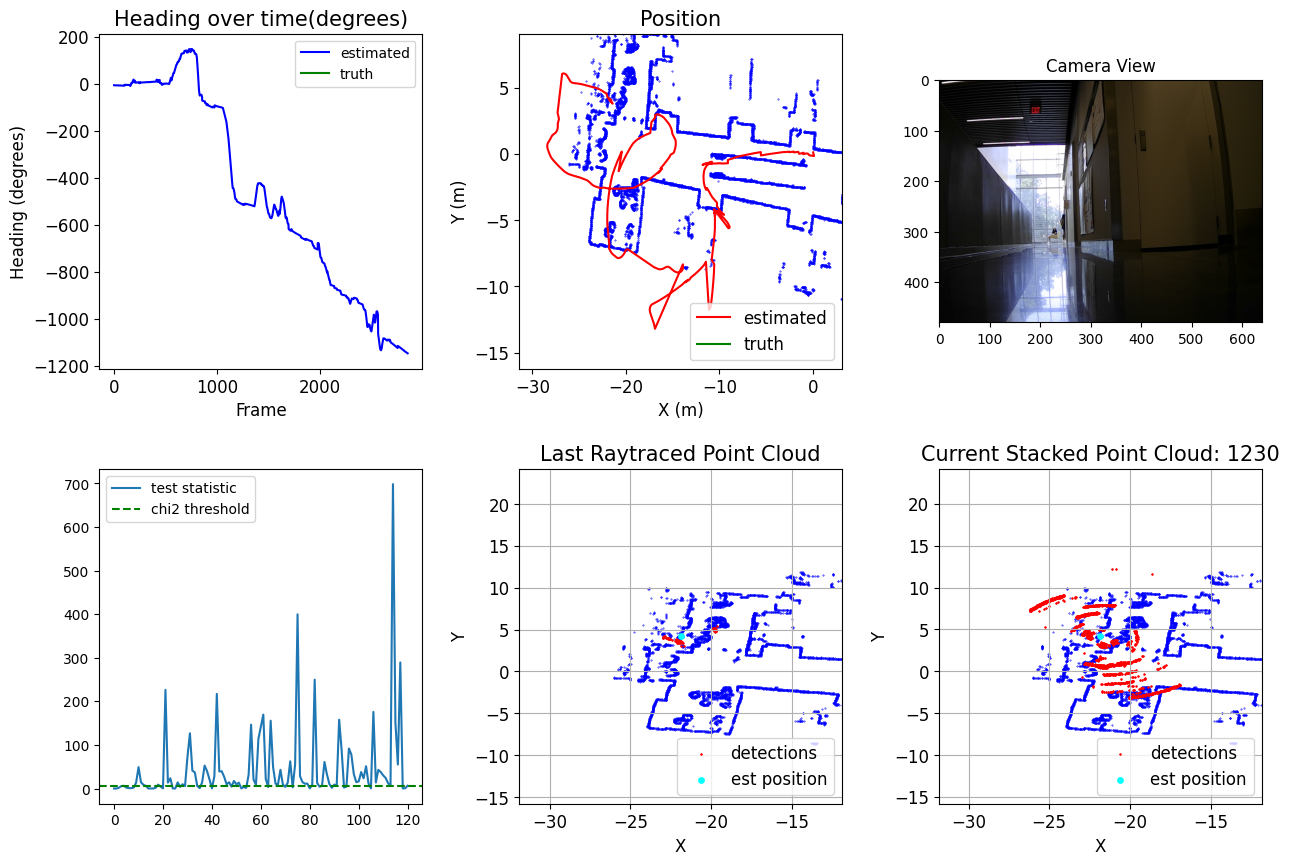

In [16]:
test_bench.plot_compilation(
    idx=end_idx-1,
    show=True
)

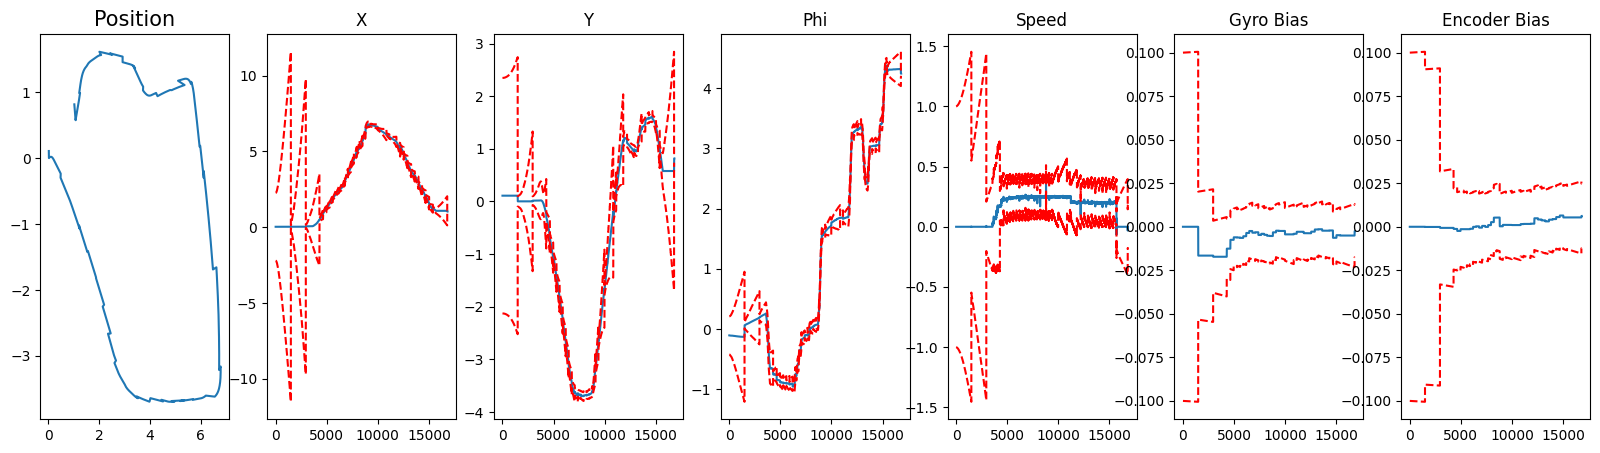

In [ ]:
#plot kalman state history
kalman_plotter = PlotterKalman()

kalman_plotter.plot_kalman_result_history(
    x_history=np.array(test_bench.history_filter_est),
    p_history=np.array(test_bench.history_filter_p),
    idx=-1
)

IndexError: list index out of range

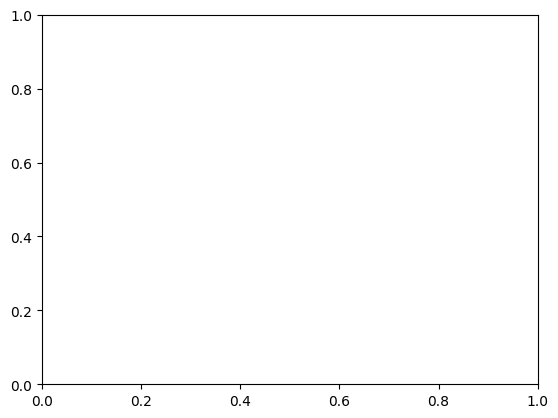

In [ ]:
#plotting the saved ray traced point clouds
# plot the lidar point cloud
idx = 44
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=test_bench.history_pc_stacker_point_clouds[idx],
    heading_rad=test_bench.history_pc_stacker_heading_rad[idx],
    pose_m=test_bench.history_pc_stacker_position_m[idx],
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show

In [ ]:
test_bench.analyze()

,Metric,Euclidian,x,y,phi
0,Mean,0.161194,0.066543,0.019730,-0.003252
1,Variance,0.004424,0.017430,0.008160,0.009208
2,Median,0.155140,0.109687,0.031836,0.013324
3,0.9th percentile,0.236317,0.221632,0.162050,0.190053


## Debugging (testing ray tracing)

In [ ]:
from odometry.point_cloud_processing.vel_filtering import VelFiltering

if(test_bench.vel_filtering_enabled):
    detections = dataset.get_radar_detections(idx)
    ego_x_vel = dataset.get_vehicle_vel_data(idx)[0,1]
    vehicle_vel = np.array([ego_x_vel,0.0])
    
    vel_filter = VelFiltering(filter_threshold)
    
    dynamic_objects = vel_filter.get_dynamic_detections(detections,vehicle_vel)
    print(dynamic_objects)
else:
    print("Velocity Filtering Disabled")

NameError: name 'idx' is not defined

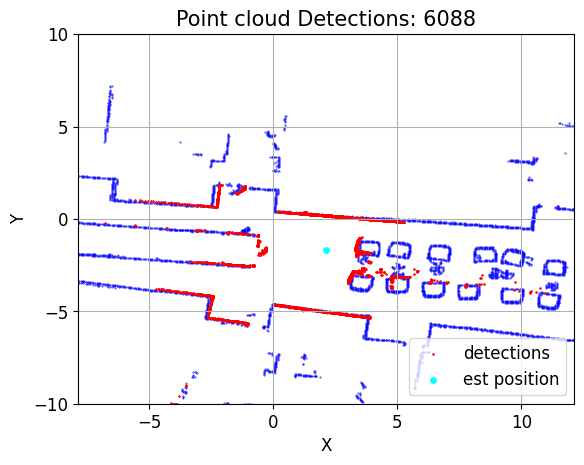

In [ ]:
# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.plot_lidar_points_on_map(
    idx=end_idx-1,
    heading_rad=test_bench.gt_localizer.current_heading_rad,
    pose_m=test_bench.gt_localizer.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show()

0.3978698249253231
9.617472171783447


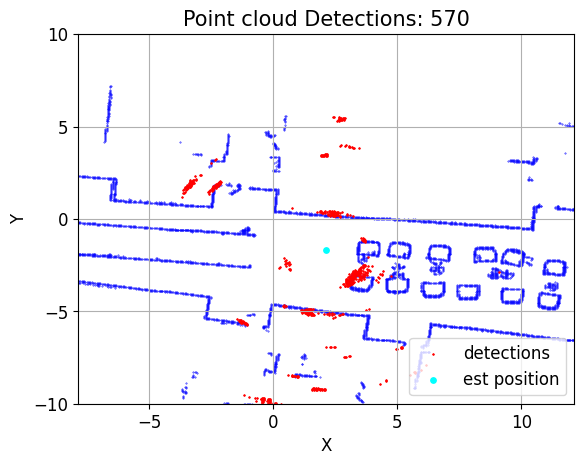

In [ ]:
combined_point_cloud = test_bench.point_cloud_stacker.get_points()
print(test_bench.point_cloud_stacker.get_rel_distance_m())
print(test_bench.point_cloud_stacker.get_elapsed_time())

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=combined_point_cloud,
    heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    pose_m=test_bench.point_cloud_stacker.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show()

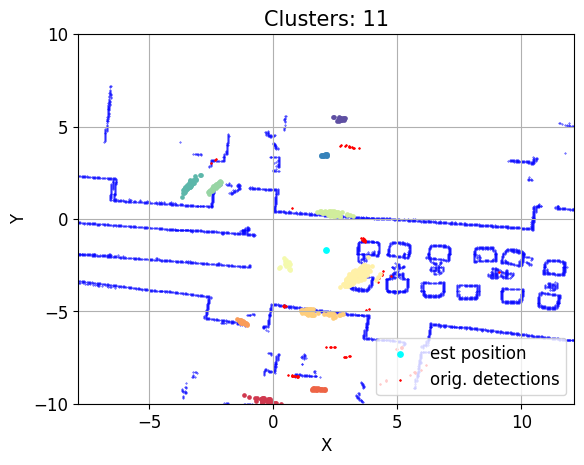

In [ ]:
from odometry.point_cloud_processing.multipath import MultiPath
from odometry.supportFns import rotation_functions
from odometry.supportFns import coordinate_systems

stacked_pc_cart = test_bench.point_cloud_stacker.get_points()

multipath = MultiPath(
    clustering_eps=0.5,
    clustering_min_samples=15
)

labels = multipath._cluster_points(stacked_pc_cart)

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detection_clusters_on_map(
    current_points=stacked_pc_cart,
    labels=labels,
    heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    pose_m=test_bench.point_cloud_stacker.current_pose_m,
    ax=ax,
    plot_raw_detections=True,
    show=False
)

ax.set_ylim(-10,10)
plt.show()

In [ ]:
from tqdm import tqdm 

for i in tqdm(range(1000)):
    stacked_pc_cart = test_bench.point_cloud_stacker.get_points()
    valid_stacked_pc_cart = multipath.remove_multipath(stacked_pc_cart)

100%|██████████| 1000/1000 [00:03<00:00, 280.79it/s]


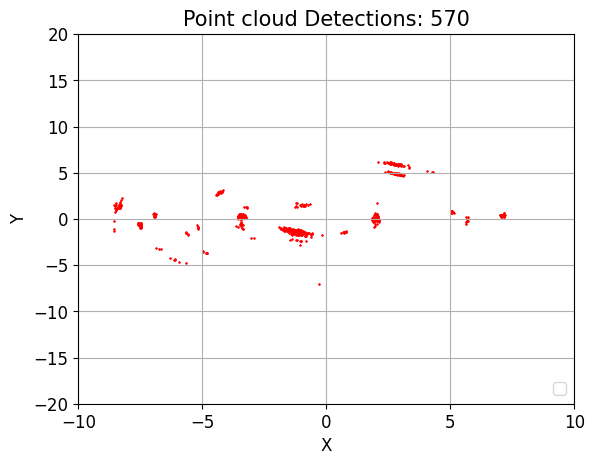

In [ ]:
test_bench.plotter_localization.plot_detections(
    stacked_pc_cart,
    show=True
)

[-1  0  1  2  3  4  5  6  7  8  9]


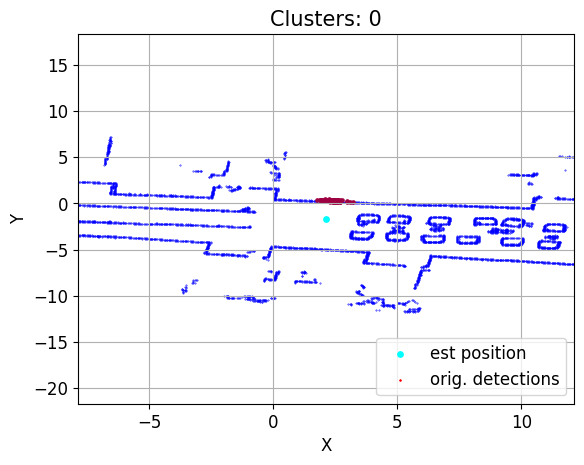

In [ ]:
labels = test_bench.multipath._cluster_points(stacked_pc_cart)

print(np.unique(labels))
cluster_to_plot = 6
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detection_clusters_on_map(
    current_points=stacked_pc_cart[labels==cluster_to_plot],
    labels=labels[labels==cluster_to_plot],
    heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    pose_m=test_bench.point_cloud_stacker.current_pose_m,
    ax=ax,
    plot_raw_detections=True,
    show=False
)

original angle bounds: [0.024952116067732615, 0.09441051555771324], range: 7.213426574479789


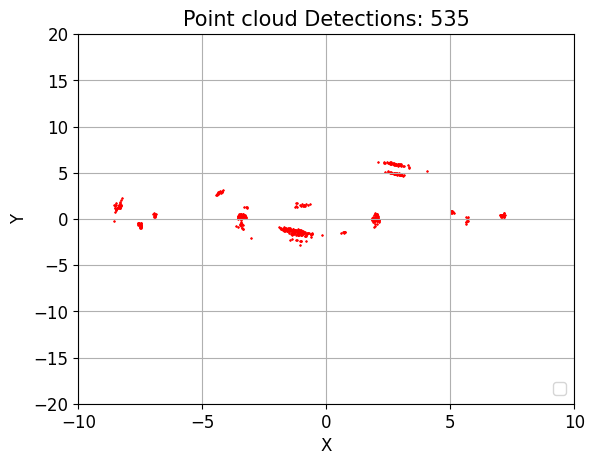

In [ ]:
pc_polar = coordinate_systems.cartesian_to_polar(stacked_pc_cart)
#enable tracking for labels and valid points
unique_labels = np.unique(labels)[1:] #remove the -1 label
valid_points = np.ones(pc_polar.shape[0],dtype=bool)
#handle points already not in a cluster
valid_points[labels==-1] = 0

#for each cluster determine the range of its closest point
cluster_ranges = np.array([
    np.min(pc_polar[labels==cluster_id,0]) for \
    cluster_id in unique_labels
])

#sort the clusters by their ranges
sorted_idxs = np.argsort(cluster_ranges)


cluster_idx = 9
cluster_points = pc_polar[labels==unique_labels[cluster_idx]]

#get the maximum range and angle bounds of the cluster
angle_bounds = [np.min(cluster_points[:,1]),np.max([cluster_points[:,1]])]
max_range = np.max(cluster_points[:,0])
print("original angle bounds: {}, range: {}".format(angle_bounds,max_range))

#handle special case where points are clustered around -pi,pi
if angle_bounds[1] - angle_bounds[0] > np.pi: #assume no cluster occupies more than +pi
    #determine the correct bounds

    #set the positive bound
    angle_bounds[1] = np.min(cluster_points[cluster_points[:,1] > 0,1])
    #set the negative bound
    angle_bounds[0] = np.max(cluster_points[cluster_points[:,1] < 0,1])

    print("new angle bounds: {}, range: {}".format(angle_bounds,max_range))

    #identify indicies of points that are past these points
    invalid_idxs = \
        (pc_polar[:,0] > max_range) & \
        ((pc_polar[:,1] > angle_bounds[1]) | \
        (pc_polar[:,1] < angle_bounds[0]))
else: #standard case
    invalid_idxs = \
        (pc_polar[:,0] > max_range) & \
        (pc_polar[:,1] < angle_bounds[1]) & \
        (pc_polar[:,1] > angle_bounds[0])

valid_points[invalid_idxs] = 0

valid_stacked_pc_cart = stacked_pc_cart[valid_points,:]

test_bench.plotter_localization.plot_detections(
    valid_stacked_pc_cart,
    show=True
)


<function matplotlib.pyplot.show(close=None, block=None)>

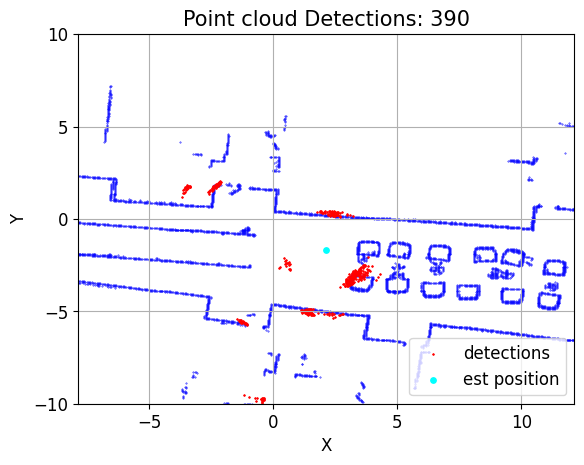

In [ ]:
#get the remaining valid points and re-cluster them
valid_stacked_pc_cart = multipath.remove_multipath(stacked_pc_cart)

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=valid_stacked_pc_cart,
    heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    pose_m=test_bench.point_cloud_stacker.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show

Filter estimate: heading: -4.844034798660762 rad, pose: [ 2.1354598  -1.67777076] m
New estimate: heading: -4.774971377728044 rad, pose: [ 2.07461352 -1.75594968] m
GT: heading: -4.778693805237316 rad, pose: [ 2.13304747 -1.6766435 ] m


<function matplotlib.pyplot.show(close=None, block=None)>

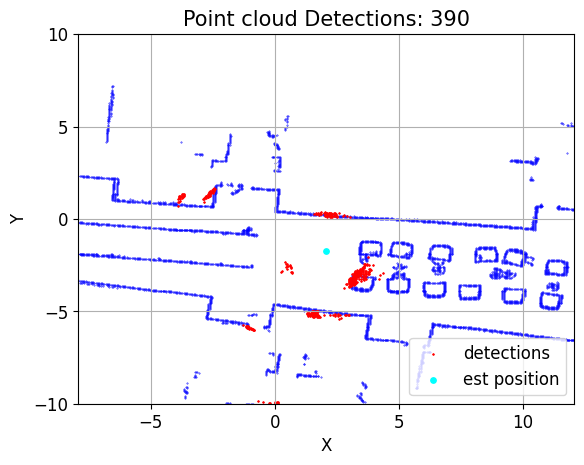

In [ ]:
#perform an ICP update
test_bench.localizer.icp_best_points_percentile = 95
est_heading_rad,est_pose_m = test_bench.localizer.update_odometry(
    points=valid_stacked_pc_cart,
    estimated_heading_rad=test_bench.filter.x[2],
    estimated_pose_m=np.array(
        [test_bench.filter.x[0],
         test_bench.filter.x[1]])
)

print("Filter estimate: heading: {} rad, pose: {} m".format(
    test_bench.filter.x[2],
    np.array(
        [test_bench.filter.x[0],
         test_bench.filter.x[1]])
))
print("New estimate: heading: {} rad, pose: {} m".format(
    est_heading_rad,est_pose_m
))
print("GT: heading: {} rad, pose: {} m".format(
    test_bench.gt_localizer.current_heading_rad,
    test_bench.gt_localizer.current_pose_m
))

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=valid_stacked_pc_cart,
    heading_rad=est_heading_rad,
    pose_m=est_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show